---

# Lab 8: Exploring Standard PyTorch Vision Models

Before diving into the progressive CNN design, let's explore some well-known architectures available in `torchvision.models`. This section will demonstrate how to:

- Load pre-trained models.
- Adapt their final classification layer to our 10-class Imagenette-160 dataset.
- Inspect their trainable parameters.
- Measure a basic inference time.
- Compare these metrics across different models.

In [1]:
import torch
import random
import numpy as np
import torch.nn as nn # Added nn import here as well for count_parameters

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

Using device: cuda


### CIFAR-10 Data Preparation for Pre-trained Model Evaluation

To use real images for inference time measurement in the pre-lab section, we'll prepare a small CIFAR-10 dataset. This dataset will provide actual image data to the models.

We will use `PRELAB_IMAGE_SIZE` (256x256) for the image dimensions, as defined in the original pre-lab setup.

In [2]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms # Import transforms module
from torch.utils.data import DataLoader

# Define the number of classes and image size for CIFAR-10 in this lab section only
PRELAB_NUM_CLASSES = 10 # Adding PRELAB_NUM_CLASSES here as it's a related constant
PRELAB_IMAGE_SIZE = 256 # Moved from cell 3c13b33e
NUM_WORKERS = 2 # Assuming NUM_WORKERS is defined elsewhere; moved here for self-containment.

# Define CIFAR-10 specific transforms, resizing to PRELAB_IMAGE_SIZE
cifar10_transform = transforms.Compose([
    transforms.Resize(PRELAB_IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# Download and load CIFAR-10 test set
cifar10_test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=cifar10_transform)

# Create a DataLoader for CIFAR-10 for evaluation
cifar10_eval_loader = DataLoader(
    cifar10_test_dataset,
    batch_size=1, # Use batch size 1 for single image inference time measurement
    shuffle=False,
    num_workers=NUM_WORKERS, # Reuse NUM_WORKERS from main settings
    pin_memory=(device.type == "cuda"),
)

print(f"CIFAR-10 test dataset size: {len(cifar10_test_dataset)}")

CIFAR-10 test dataset size: 10000


In [3]:
import torchvision.models as models
import time

# Define the number of classes and image size for CIFAR-10 in this lab section only
PRELAB_NUM_CLASSES = 10
PRELAB_IMAGE_SIZE = 256 # Changed from 224 to 256 to further accommodate pre-trained models

def load_and_adapt_model(model_name: str):
    model = None
    if model_name == "AlexNet":
        model = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, PRELAB_NUM_CLASSES)
    elif model_name == "VGG16":
        model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, PRELAB_NUM_CLASSES)
    elif model_name == "GoogLeNet":
        model = models.googlenet(weights=models.GoogLeNet_Weights.IMAGENET1K_V1)
        model.fc = nn.Linear(model.fc.in_features, PRELAB_NUM_CLASSES)
    elif model_name == "ResNet18":
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        model.fc = nn.Linear(model.fc.in_features, PRELAB_NUM_CLASSES)
    elif model_name == "MobileNetV2":
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, PRELAB_NUM_CLASSES)
    elif model_name == "EfficientNetB0": # Often includes SE blocks
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, PRELAB_NUM_CLASSES)
    else:
        raise ValueError(f"Unknown model: {model_name}")

    model = model.to(device)
    return model

def measure_inference_time(model: nn.Module, data_loader, num_warmup=10, num_runs=50):
    model.eval()
    # Get a batch of real images from the data_loader
    # We'll repeat the same batch for num_runs to ensure consistent input size and type
    for inputs, _ in data_loader:
        dummy_input = inputs.to(device)
        break # Take only the first batch

    if dummy_input.shape[0] != 1: # Ensure batch size is 1 for single image inference
        dummy_input = dummy_input[0].unsqueeze(0)

    # Warm-up runs
    for _ in range(num_warmup):
        _ = model(dummy_input)

    # Measure inference time
    start_time = time.perf_counter()
    with torch.no_grad():
        for _ in range(num_runs):
            _ = model(dummy_input)
    end_time = time.perf_counter()

    return (end_time - start_time) / num_runs * 1000 # Average time in ms

comparison_data = []

model_names_to_compare = [
    "AlexNet",
    "VGG16",
    "GoogLeNet",
    "ResNet18",
    "MobileNetV2",
    "EfficientNetB0",
]

for name in model_names_to_compare:
    print(f"Processing {name}...")
    model = load_and_adapt_model(name)
    params = count_parameters(model)
    inference_ms = measure_inference_time(model, cifar10_eval_loader) # Pass the DataLoader here

    # Generate a dummy output to get its shape for checking
    # Use a dummy input with the correct shape, which is now taken from the DataLoader
    for inputs, _ in cifar10_eval_loader:
        dummy_input_for_shape = inputs[0].unsqueeze(0).to(device)
        break

    with torch.no_grad():
        output = model(dummy_input_for_shape)
        output_shape = tuple(output.shape)

    comparison_data.append({
        "Model": name,
        "Trainable Parameters": params,
        "Inference Time (ms)": f"{inference_ms:.2f}",
        "Output Shape": output_shape
    })

Processing AlexNet...
Processing VGG16...
Processing GoogLeNet...
Processing ResNet18...
Processing MobileNetV2...
Processing EfficientNetB0...


In [4]:
import pandas as pd


comparison_df_pretrained = pd.DataFrame(comparison_data)
display(comparison_df_pretrained)

,Model,Trainable Parameters,Inference Time (ms),Output Shape
0,AlexNet,57044810,0.22,"(1, 10)"
1,VGG16,134301514,1.17,"(1, 10)"
2,GoogLeNet,5610154,1.84,"(1, 10)"
3,ResNet18,11181642,0.63,"(1, 10)"
4,MobileNetV2,2236682,1.25,"(1, 10)"
5,EfficientNetB0,4020358,1.94,"(1, 10)"


## Discussion on Pre-trained Models

From the comparison table, we can observe various characteristics of these popular architectures:

-   **AlexNet** is one of the earliest deep CNNs. It tends to have fewer parameters than VGG but more than some efficient models.
-   **VGG16** is known for its uniform architecture with many convolutional layers. It typically has a very high number of parameters due to its fully connected layers, making it computationally expensive.
-   **GoogLeNet** introduced the Inception module, allowing the network to learn features at multiple scales. It's designed to be more computationally efficient than VGG with fewer parameters.
-   **ResNet18** introduced residual connections, which help in training very deep networks by mitigating the vanishing gradient problem. It offers a good balance between performance and parameter count for many tasks.
-   **MobileNetV2** focuses on mobile and embedded vision applications by using depthwise separable convolutions, significantly reducing parameters and computation while maintaining decent accuracy.
-   **EfficientNetB0** is part of a family of models that systematically scale up networks using a compound scaling method. It incorporates squeeze-and-excitation blocks (SENet-style) for channel attention, providing a strong balance of accuracy and efficiency for its size.

### Summary of Other Available Pre-trained Models

| Pre-trained Models | DenseNet Family    | MNASNet Family  | ShuffleNetV2 Family    | SqueezeNet Family | VGG Family      | ResNet Family   | Inception Family | MobileNet Family    |
|:-------------------|:-------------------|:----------------|:-----------------------|:------------------|:----------------|:----------------|:-----------------|:--------------------|
| AlexNet            | densenet121        | mnasnet0_5      | shufflenet_v2_x0_5     | squeezenet1_0     | vgg11           | resnet18        | googlenet        | mobilenet_v2        |
| EfficientNetB0     | densenet161        | mnasnet0_75     | shufflenet_v2_x1_0     | squeezenet1_1     | vgg11_bn        | resnet34        | inception_v3     | mobilenet_v3_large  |
|                    | densenet169        | mnasnet1_0      | shufflenet_v2_x1_5     |                   | vgg13           | resnet50        |                  | mobilenet_v3_small  |
|                    | densenet201        | mnasnet1_3      | shufflenet_v2_x2_0     |                   | vgg13_bn        | resnet101       |                  |                     |
|                    |                    |                 |                        |                   | vgg16           | resnet152       |                  |                     |
|                    |                    |                 |                        |                   | vgg16_bn        |                 |                  |                     |
|                    |                    |                 |                        |                   | vgg19           |                 |                  |                     |
|                    |                    |                 |                        |                   | vgg19_bn        |                 |                  |                     |

# Q3 Progressive CNN Design on Imagenette-160

This notebook is intentionally organized to mirror the **student implementation order**:

1. build the **baseline CNN**;
2. deepen it into a **VGG-style** model;
3. replace one stage with an **Inception / GoogLeNet-style** block;
4. replace one stage with a **ResNet-style** residual block;
5. swap the residual convolutions for **MobileNet-style depthwise-separable** convolutions;
6. plug in an **SE block** for channel attention.


We use **Imagenette-160**, a small 10-class natural-image dataset derived from ImageNet, so the lab remains practical on a standard GPU.

## Question 3 overview

In this question, you will:

- train a baseline CNN on an ImageNet-style RGB dataset;
- evaluate it using:
  - test accuracy,
  - confusion matrix,
  - per-class precision,
  - per-class recall,
  - per-class F1-score;
- progressively modify the network one architectural block at a time:
  - **M0** baseline serial CNN
  - **M1** VGG-style deeper serial blocks
  - **M2** GoogLeNet-style multi-branch stage
  - **M3** ResNet-style residual stage
  - **M4** MobileNet-style depthwise-separable residual stage
  - **M5** SENet-style residual stage with channel attention

All models use the **same dataset split, optimizer, batch size, and number of epochs** so the comparison stays fair.

## 0. Imports

In [5]:
import copy
import random
import tarfile
import urllib.request
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from IPython.display import display

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    ConfusionMatrixDisplay,
)

## 1. Reproducibility and runtime settings

In [6]:

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


### Training settings

Use one fixed optimizer and one fixed batch size for all models.

`QUICK_RUN=True` is useful during the lab when you only want to verify that every section runs end-to-end.

In [7]:
QUICK_RUN = False   # set to True for a faster smoke test
FORCE_RETRAIN = True

BATCH_SIZE = 64 if device.type == "cuda" else 32
NUM_EPOCHS = 10 if not QUICK_RUN else 5
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 2
IMAGE_SIZE = 160

# Smaller balanced subsets for quick debugging
QUICK_TRAIN_PER_CLASS = 120
QUICK_VAL_PER_CLASS = 30
QUICK_TEST_PER_CLASS = 40

print({
    "QUICK_RUN": QUICK_RUN,
    "BATCH_SIZE": BATCH_SIZE,
    "NUM_EPOCHS": NUM_EPOCHS,
    "LEARNING_RATE": LEARNING_RATE,
    "WEIGHT_DECAY": WEIGHT_DECAY,
    "IMAGE_SIZE": IMAGE_SIZE,
})

{'QUICK_RUN': False, 'BATCH_SIZE': 64, 'NUM_EPOCHS': 10, 'LEARNING_RATE': 0.001, 'WEIGHT_DECAY': 0.0001, 'IMAGE_SIZE': 160}


## 2. Download / locate the Imagenette-160 dataset

In [8]:
DATA_ROOT = Path("./data")
DATA_ROOT.mkdir(parents=True, exist_ok=True)

IMAGENETTE_URL = "https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-160.tgz"
ARCHIVE_PATH = DATA_ROOT / "imagenette2-160.tgz"
EXTRACTED_DIR = DATA_ROOT / "imagenette2-160"

def download_imagenette(url: str = IMAGENETTE_URL,
                        archive_path: Path = ARCHIVE_PATH,
                        extracted_dir: Path = EXTRACTED_DIR) -> Path:
    if extracted_dir.exists():
        print(f"Dataset already available at: {extracted_dir}")
        return extracted_dir

    if not archive_path.exists():
        print("Downloading Imagenette-160...")
        urllib.request.urlretrieve(url, archive_path)
        print(f"Saved to: {archive_path}")
    else:
        print(f"Archive already exists at: {archive_path}")

    print("Extracting archive...")
    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(DATA_ROOT)

    print(f"Extraction completed: {extracted_dir}")
    return extracted_dir

dataset_dir = download_imagenette()
train_dir = dataset_dir / "train"
test_dir = dataset_dir / "val"

print("Train dir exists:", train_dir.exists())
print("Test dir exists:", test_dir.exists())

Dataset already available at: data/imagenette2-160
Train dir exists: True
Test dir exists: True


## 3. Transforms, label names, and dataset wrappers

In [9]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(192),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

LABEL_MAP = {
    "n01440764": "tench",
    "n02102040": "English springer",
    "n02979186": "cassette player",
    "n03000684": "chain saw",
    "n03028079": "church",
    "n03394916": "French horn",
    "n03417042": "garbage truck",
    "n03425413": "gas pump",
    "n03445777": "golf ball",
    "n03888257": "parachute",
}

class SampleListDataset(Dataset):
    def __init__(self, samples: List[Tuple[str, int]], transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, target = self.samples[idx]
        image = Image.open(path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image, target

def split_samples_by_class(samples: List[Tuple[str, int]],
                           val_fraction: float = 0.10,
                           seed: int = SEED):
    rng = random.Random(seed)
    by_class = {}
    for path, label in samples:
        by_class.setdefault(label, []).append((path, label))

    train_samples, val_samples = [], []
    for label, class_samples in by_class.items():
        rng.shuffle(class_samples)
        n_val = max(1, int(len(class_samples) * val_fraction))
        val_samples.extend(class_samples[:n_val])
        train_samples.extend(class_samples[n_val:])

    rng.shuffle(train_samples)
    rng.shuffle(val_samples)
    return train_samples, val_samples

def make_balanced_subset(samples: List[Tuple[str, int]],
                         max_per_class: int,
                         seed: int = SEED):
    rng = random.Random(seed)
    by_class = {}
    for sample in samples:
        by_class.setdefault(sample[1], []).append(sample)

    subset = []
    for label, class_samples in by_class.items():
        rng.shuffle(class_samples)
        subset.extend(class_samples[:max_per_class])

    rng.shuffle(subset)
    return subset

## 4. Create train / validation / test datasets and dataloaders

In [10]:
train_pool = datasets.ImageFolder(train_dir)
test_pool = datasets.ImageFolder(test_dir)

class_ids = train_pool.classes
class_names = [LABEL_MAP.get(c, c) for c in class_ids]

print("Class IDs:", class_ids)
print("Readable class names:", class_names)
print("Official training images:", len(train_pool.samples))
print("Official validation/test images:", len(test_pool.samples))

train_samples, val_samples = split_samples_by_class(train_pool.samples, val_fraction=0.10, seed=SEED)
test_samples = list(test_pool.samples)

if QUICK_RUN:
    train_samples = make_balanced_subset(train_samples, QUICK_TRAIN_PER_CLASS, seed=SEED)
    val_samples = make_balanced_subset(val_samples, QUICK_VAL_PER_CLASS, seed=SEED)
    test_samples = make_balanced_subset(test_samples, QUICK_TEST_PER_CLASS, seed=SEED)

train_dataset = SampleListDataset(train_samples, transform=train_transform)
val_dataset = SampleListDataset(val_samples, transform=eval_transform)
test_dataset = SampleListDataset(test_samples, transform=eval_transform)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
    generator=g,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

Class IDs: ['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079', 'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']
Readable class names: ['tench', 'English springer', 'cassette player', 'chain saw', 'church', 'French horn', 'garbage truck', 'gas pump', 'golf ball', 'parachute']
Official training images: 9469
Official validation/test images: 3925
Train size: 8525
Validation size: 944
Test size: 3925


## 5. Visualize a few training examples

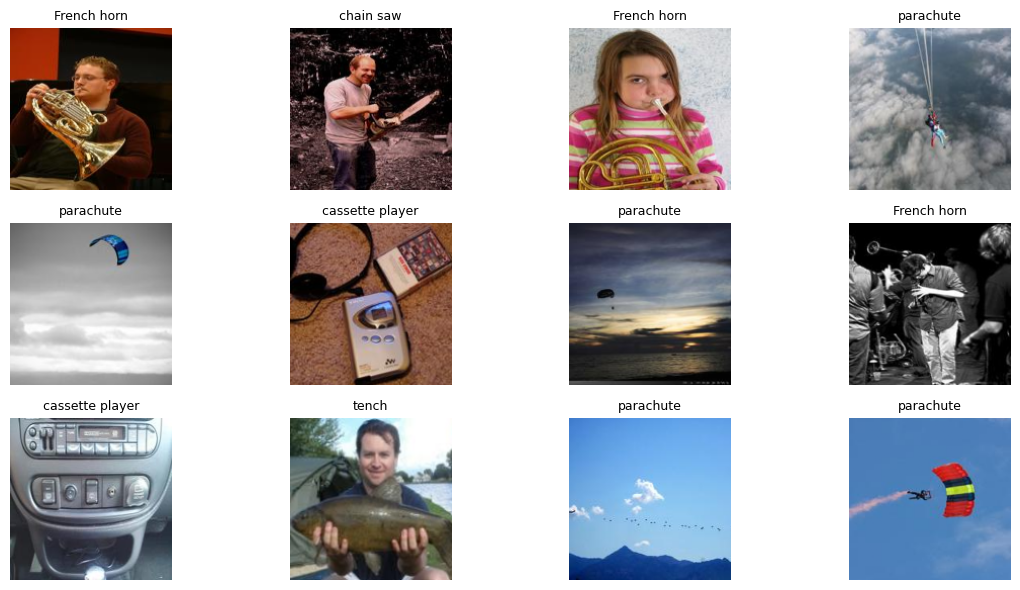

In [11]:
def denormalize(img_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return (img_tensor.cpu() * std) + mean

fig, axes = plt.subplots(3, 4, figsize=(12, 6))
for ax in axes.flatten():
    idx = random.randrange(len(train_dataset))
    image, label = train_dataset[idx]
    image = denormalize(image).clamp(0, 1)
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(class_names[label], fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 6. Shared helper functions

These helpers are **not architecture-specific**.  
They handle training, evaluation, plotting, metrics, checkpoints, and shape inspection.

The architectural code itself will appear **one model at a time** in later sections.

In [12]:
def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

@torch.no_grad()
def evaluate_loss_and_accuracy(model: nn.Module,
                               loader: DataLoader,
                               criterion: nn.Module) -> Tuple[float, float]:
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * y.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_count += y.size(0)

    return total_loss / total_count, total_correct / total_count

@torch.no_grad()
def predict_labels(model: nn.Module, loader: DataLoader):
    model.eval()
    y_true, y_pred = [], []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        preds = logits.argmax(dim=1).cpu().numpy()
        y_true.extend(y.numpy())
        y_pred.extend(preds)
    return np.array(y_true), np.array(y_pred)

def classification_metrics(y_true, y_pred, class_names):
    acc = accuracy_score(y_true, y_pred)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    report_dict = classification_report(
        y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0
    )
    report_df = pd.DataFrame(report_dict).transpose()

    # Fix the accuracy row
    report_df.loc["accuracy", "precision"] = np.nan
    report_df.loc["accuracy", "recall"] = np.nan
    report_df.loc["accuracy", "f1-score"] = report_dict["accuracy"]
    report_df.loc["accuracy", "support"] = np.nan

    cm = confusion_matrix(y_true, y_pred)
    return {
        "accuracy": acc,
        "macro_precision": macro_p,
        "macro_recall": macro_r,
        "macro_f1": macro_f1,
        "report_df": report_df,
        "report_dict": report_dict,
        "confusion_matrix": cm,
    }

def plot_history(history: Dict[str, List[float]], title: str):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["train_loss"], label="train loss")
    axes[0].plot(history["val_loss"], label="val loss")
    axes[0].set_title(f"{title} — loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history["train_acc"], label="train acc")
    axes[1].plot(history["val_acc"], label="val acc")
    axes[1].set_title(f"{title} — accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

def plot_confusion(cm: np.ndarray, class_names: List[str], title: str):
    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

def train_model(model: nn.Module,
                train_loader: DataLoader,
                val_loader: DataLoader,
                num_epochs: int = NUM_EPOCHS,
                lr: float = LEARNING_RATE,
                weight_decay: float = WEIGHT_DECAY):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
    best_state = copy.deepcopy(model.state_dict())
    best_val_acc = -float("inf")

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
    }

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        running_correct = 0
        running_count = 0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                logits = model(x)
                loss = criterion(logits, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * y.size(0)
            running_correct += (logits.argmax(dim=1) == y).sum().item()
            running_count += y.size(0)

        train_loss = running_loss / running_count
        train_acc = running_correct / running_count
        val_loss, val_acc = evaluate_loss_and_accuracy(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"Epoch {epoch + 1:02d}/{num_epochs} | "
            f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f}"
        )

    model.load_state_dict(best_state)
    return model, history

CHECKPOINT_DIR = Path("./checkpoints_lab8_q3_reorganized")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

def save_checkpoint(model_name: str, model: nn.Module, history: Dict[str, List[float]]):
    path = CHECKPOINT_DIR / f"{model_name}.pt"
    torch.save({"state_dict": model.state_dict(), "history": history}, path)
    print(f"Saved checkpoint to: {path}")

def load_checkpoint(model_name: str, model: nn.Module):
    path = CHECKPOINT_DIR / f"{model_name}.pt"
    if not path.exists():
        return None
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint["state_dict"])
    return checkpoint["history"]

def inspect_model_shapes(model: nn.Module,
                         input_shape: Tuple[int, int, int, int] = (1, 3, IMAGE_SIZE, IMAGE_SIZE)):
    model = model.to(device)
    x = torch.randn(*input_shape).to(device)
    with torch.no_grad():
        feats = model.forward_features(x)
        logits = model(x)

    rows = [
        ["Input", tuple(x.shape)],
        ["Stem output", tuple(feats["stem"].shape)],
        ["Stage 1 output", tuple(feats["stage1"].shape)],
        ["Stage 2 output", tuple(feats["stage2"].shape)],
        ["Global average pooling", tuple(feats["gap"].shape)],
        ["Classifier output", tuple(logits.shape)],
    ]
    return pd.DataFrame(rows, columns=["Location", "Shape"])

RESULTS = {}

## 7. Shared low-level layers

These are the only shared building blocks we define **before** the model subsections:

- `ConvBNReLU`
- `ConvBN`
- `CommonStem`

Everything else will be introduced only when the corresponding model appears.

In [13]:
class ConvBNReLU(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size,
                      stride=stride, padding=padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class ConvBN(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size,
                      stride=stride, padding=padding, bias=False),
            nn.BatchNorm2d(out_channels),
        )

    def forward(self, x):
        return self.block(x)

class CommonStem(nn.Module):
    def __init__(self):
        super().__init__()
        self.block = nn.Sequential(
            ConvBNReLU(3, 32, kernel_size=3, stride=2, padding=1),   # 160 -> 80
            ConvBNReLU(32, 64, kernel_size=3, stride=1, padding=1),  # 80 -> 80
            nn.MaxPool2d(2, 2),                                      # 80 -> 40
        )

    def forward(self, x):
        return self.block(x)

---

# Question 3(a)–(c) — Baseline model $M_0$

We start with a simple serial CNN.

### Baseline architecture
- common stem
- **Stage 1:** one 3×3 convolution, then max-pooling
- **Stage 2:** one 3×3 convolution, then max-pooling
- global average pooling
- final linear classifier

In [14]:
class BaselineStage(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            ConvBNReLU(in_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.MaxPool2d(2, 2),
        )

    def forward(self, x):
        return self.block(x)

class ModelM0(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.stem = CommonStem()
        self.stage1 = BaselineStage(64, 64)
        self.stage2 = BaselineStage(64, 128)
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(128, num_classes)

    def forward_features(self, x):
        outputs = {}
        x = self.stem(x)
        outputs["stem"] = x
        x = self.stage1(x)
        outputs["stage1"] = x
        x = self.stage2(x)
        outputs["stage2"] = x
        x = self.gap(x)
        x = torch.flatten(x, 1)
        outputs["gap"] = x
        return outputs

    def forward(self, x):
        feats = self.forward_features(x)
        return self.classifier(feats["gap"])

### 3(a) — Inspect the baseline output dimensions and parameter count

In [15]:
m0 = ModelM0(num_classes=len(class_names))
display(inspect_model_shapes(m0))
print("M0 trainable parameters:", f"{count_parameters(m0):,}")

,Location,Shape
0,Input,"(1, 3, 160, 160)"
1,Stem output,"(1, 64, 40, 40)"
2,Stage 1 output,"(1, 64, 20, 20)"
3,Stage 2 output,"(1, 128, 10, 10)"
4,Global average pooling,"(1, 128)"
5,Classifier output,"(1, 10)"


M0 trainable parameters: 131,754


### 3(b) — Train the baseline model

Use the same optimizer and batch size you declared earlier.
If a checkpoint already exists, the notebook will reuse it unless `FORCE_RETRAIN=True`.

/tmp/ipykernel_16065/4083656842.py:100: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
/tmp/ipykernel_16065/4083656842.py:123: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Epoch 01/10 | train_loss=1.6696 | train_acc=0.4537 | val_loss=1.5122 | val_acc=0.4672
Epoch 02/10 | train_loss=1.3570 | train_acc=0.5619 | val_loss=1.5194 | val_acc=0.5021
Epoch 03/10 | train_loss=1.2243 | train_acc=0.6194 | val_loss=1.3138 | val_acc=0.5667
Epoch 04/10 | train_loss=1.1175 | train_acc=0.6408 | val_loss=1.2968 | val_acc=0.5519
Epoch 05/10 | train_loss=1.0373 | train_acc=0.6748 | val_loss=1.1513 | val_acc=0.6367
Epoch 06/10 | train_loss=0.9933 | train_acc=0.6809 | val_loss=1.1861 | val_acc=0.6261
Epoch 07/10 | train_loss=0.9353 | train_acc=0.7011 | val_loss=1.1935 | val_acc=0.6367
Epoch 08/10 | train_loss=0.8915 | train_acc=0.7192 | val_loss=1.0012 | val_acc=0.6684
Epoch 09/10 | train_loss=0.8612 | train_acc=0.7288 | val_loss=1.0012 | val_acc=0.6864
Epoch 10/10 | train_loss=0.8254 | train_acc=0.7421 | val_loss=1.0133 | val_acc=0.6780
Saved checkpoint to: checkpoints_lab8_q3_reorganized/M0.pt


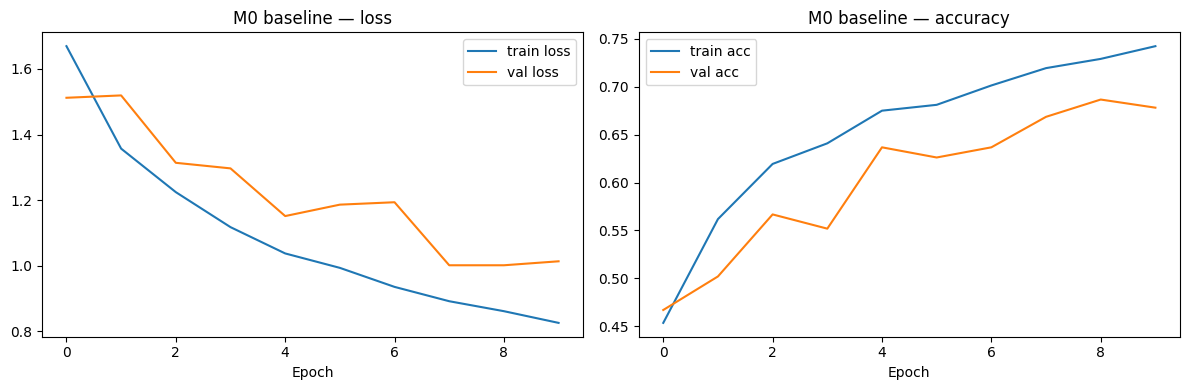

In [16]:
m0 = ModelM0(num_classes=len(class_names)).to(device)
history_m0 = None

if not FORCE_RETRAIN:
    history_m0 = load_checkpoint("M0", m0)
    if history_m0 is not None:
        print("Loaded checkpoint for M0")

if history_m0 is None:
    m0, history_m0 = train_model(m0, train_loader, val_loader)
    save_checkpoint("M0", m0, history_m0)

plot_history(history_m0, "M0 baseline")

### 3(c) — Evaluate the baseline model on the test set

M0 test accuracy: 0.6996
M0 macro-precision: 0.7206
M0 macro-recall: 0.6996
M0 macro-F1: 0.6988


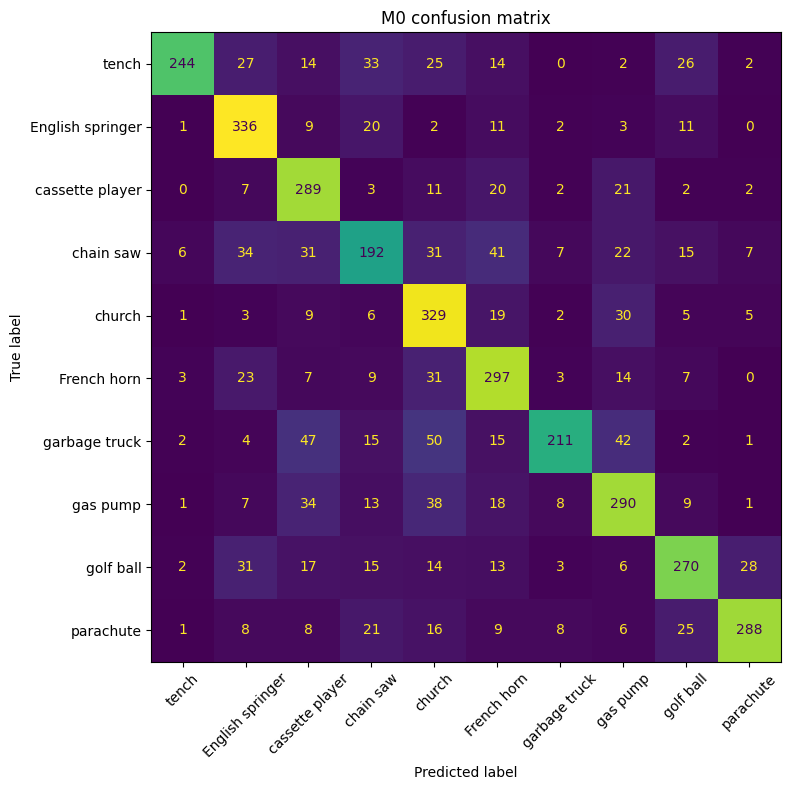

,precision,recall,f1-score,support
tench,0.934866,0.630491,0.753086,387.0
English springer,0.700000,0.850633,0.768000,395.0
cassette player,0.621505,0.809524,0.703163,357.0
chain saw,0.587156,0.497409,0.538569,386.0
church,0.601463,0.804401,0.688285,409.0
French horn,0.649891,0.753807,0.698002,394.0
garbage truck,0.857724,0.542416,0.664567,389.0
gas pump,0.665138,0.692124,0.678363,419.0
golf ball,0.725806,0.676692,0.700389,399.0
parachute,0.862275,0.738462,0.795580,390.0


{'tench': {'precision': 0.9348659003831418, 'recall': 0.6304909560723514, 'f1-score': 0.7530864197530864, 'support': 387.0}, 'English springer': {'precision': 0.7, 'recall': 0.850632911392405, 'f1-score': 0.768, 'support': 395.0}, 'cassette player': {'precision': 0.621505376344086, 'recall': 0.8095238095238095, 'f1-score': 0.7031630170316302, 'support': 357.0}, 'chain saw': {'precision': 0.5871559633027523, 'recall': 0.49740932642487046, 'f1-score': 0.5385694249649369, 'support': 386.0}, 'church': {'precision': 0.6014625228519196, 'recall': 0.80440097799511, 'f1-score': 0.6882845188284519, 'support': 409.0}, 'French horn': {'precision': 0.649890590809628, 'recall': 0.7538071065989848, 'f1-score': 0.6980023501762632, 'support': 394.0}, 'garbage truck': {'precision': 0.8577235772357723, 'recall': 0.5424164524421594, 'f1-score': 0.6645669291338583, 'support': 389.0}, 'gas pump': {'precision': 0.6651376146788991, 'recall': 0.6921241050119332, 'f1-score': 0.6783625730994152, 'support': 419.

In [17]:
y_true_m0, y_pred_m0 = predict_labels(m0, test_loader)
test_metrics_m0 = classification_metrics(y_true_m0, y_pred_m0, class_names)

print("M0 test accuracy:", f"{test_metrics_m0['accuracy']:.4f}")
print("M0 macro-precision:", f"{test_metrics_m0['macro_precision']:.4f}")
print("M0 macro-recall:", f"{test_metrics_m0['macro_recall']:.4f}")
print("M0 macro-F1:", f"{test_metrics_m0['macro_f1']:.4f}")

plot_confusion(test_metrics_m0["confusion_matrix"], class_names, "M0 confusion matrix")
display(test_metrics_m0["report_df"])
print(test_metrics_m0["report_dict"])

RESULTS["M0"] = {
    "model": m0,
    "history": history_m0,
    "test_metrics": test_metrics_m0,
    "params": count_parameters(m0),
}

---

# Question 3(d1) — Model $M_1$: VGG-style variant

### Local change from $M_0$
Replace each baseline stage with a **deeper serial block**:

- two 3×3 convolutions
- BatchNorm + ReLU after each convolution
- max-pooling at the end of the stage

The stem and classifier head stay the same.

In [18]:
class VGGStage(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            ConvBNReLU(in_channels, out_channels, kernel_size=3, stride=1, padding=1),
            ConvBNReLU(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.MaxPool2d(2, 2),
        )

    def forward(self, x):
        return self.block(x)

class ModelM1(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.stem = CommonStem()
        self.stage1 = VGGStage(64, 64)
        self.stage2 = VGGStage(64, 128)
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(128, num_classes)

    def forward_features(self, x):
        outputs = {}
        x = self.stem(x)
        outputs["stem"] = x
        x = self.stage1(x)
        outputs["stage1"] = x
        x = self.stage2(x)
        outputs["stage2"] = x
        x = self.gap(x)
        x = torch.flatten(x, 1)
        outputs["gap"] = x
        return outputs

    def forward(self, x):
        feats = self.forward_features(x)
        return self.classifier(feats["gap"])

### Inspect, train, and evaluate $M_1$

In [19]:
m1 = ModelM1(num_classes=len(class_names))
display(inspect_model_shapes(m1))
print("M1 trainable parameters:", f"{count_parameters(m1):,}")

,Location,Shape
0,Input,"(1, 3, 160, 160)"
1,Stem output,"(1, 64, 40, 40)"
2,Stage 1 output,"(1, 64, 20, 20)"
3,Stage 2 output,"(1, 128, 10, 10)"
4,Global average pooling,"(1, 128)"
5,Classifier output,"(1, 10)"


M1 trainable parameters: 316,458


/tmp/ipykernel_16065/4083656842.py:100: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
/tmp/ipykernel_16065/4083656842.py:123: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Epoch 01/10 | train_loss=1.6586 | train_acc=0.4493 | val_loss=1.5945 | val_acc=0.4746
Epoch 02/10 | train_loss=1.2698 | train_acc=0.5968 | val_loss=1.2334 | val_acc=0.5964
Epoch 03/10 | train_loss=1.1071 | train_acc=0.6450 | val_loss=1.2992 | val_acc=0.5498
Epoch 04/10 | train_loss=0.9852 | train_acc=0.6895 | val_loss=1.0584 | val_acc=0.6356
Epoch 05/10 | train_loss=0.8931 | train_acc=0.7166 | val_loss=1.4014 | val_acc=0.5254
Epoch 06/10 | train_loss=0.8437 | train_acc=0.7307 | val_loss=0.9175 | val_acc=0.7023
Epoch 07/10 | train_loss=0.7677 | train_acc=0.7510 | val_loss=1.3107 | val_acc=0.6441
Epoch 08/10 | train_loss=0.7258 | train_acc=0.7674 | val_loss=0.9144 | val_acc=0.7193
Epoch 09/10 | train_loss=0.7030 | train_acc=0.7674 | val_loss=1.1420 | val_acc=0.6409
Epoch 10/10 | train_loss=0.6346 | train_acc=0.7966 | val_loss=1.0804 | val_acc=0.6970
Saved checkpoint to: checkpoints_lab8_q3_reorganized/M1.pt


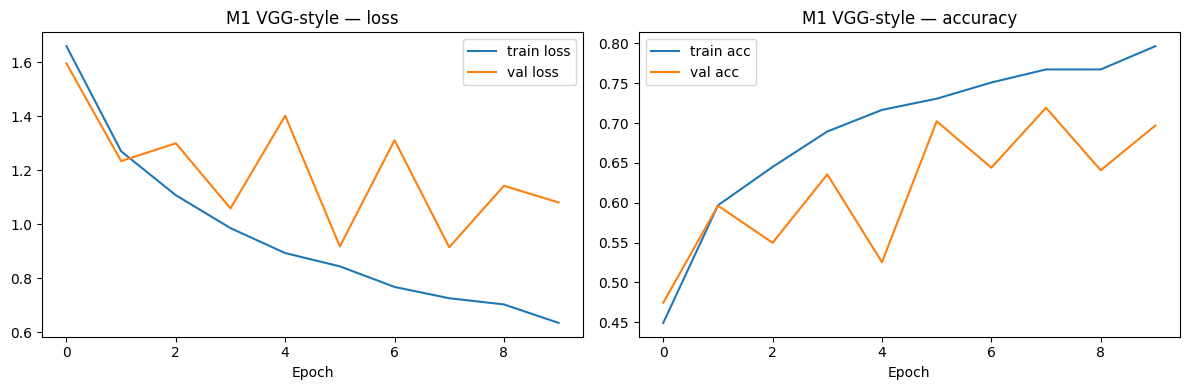

M1 test accuracy: 0.7177


In [20]:
m1 = ModelM1(num_classes=len(class_names)).to(device)
history_m1 = None

if not FORCE_RETRAIN:
    history_m1 = load_checkpoint("M1", m1)
    if history_m1 is not None:
        print("Loaded checkpoint for M1")

if history_m1 is None:
    m1, history_m1 = train_model(m1, train_loader, val_loader)
    save_checkpoint("M1", m1, history_m1)

plot_history(history_m1, "M1 VGG-style")

y_true_m1, y_pred_m1 = predict_labels(m1, test_loader)
test_metrics_m1 = classification_metrics(y_true_m1, y_pred_m1, class_names)

RESULTS["M1"] = {
    "model": m1,
    "history": history_m1,
    "test_metrics": test_metrics_m1,
    "params": count_parameters(m1),
}
print("M1 test accuracy:", f"{test_metrics_m1['accuracy']:.4f}")

---

# Question 3(d2) — Model $M_2$: GoogLeNet-style variant

### Local change from $M_1$
Keep the VGG-style Stage 1, but replace **only Stage 2** with an Inception-style multi-branch block:

- Branch 1: 1×1 conv → 32 channels
- Branch 2: 1×1 conv → 32 channels, then 3×3 conv → 48 channels
- Branch 3: 1×1 conv → 16 channels, then 5×5 conv → 16 channels
- Branch 4: 3×3 max-pooling (stride 1, pad 1), then 1×1 conv → 32 channels
- Concatenate the branch outputs → 128 channels
- Max-pool after concatenation

The stem and classifier head still stay the same.

In [21]:
class InceptionStage2(nn.Module):
    def __init__(self, in_channels=64):
        super().__init__()
        self.branch1 = ConvBNReLU(in_channels, 32, kernel_size=1, stride=1, padding=0)

        self.branch2 = nn.Sequential(
            ConvBNReLU(in_channels, 32, kernel_size=1, stride=1, padding=0),
            ConvBNReLU(32, 48, kernel_size=3, stride=1, padding=1),
        )

        self.branch3 = nn.Sequential(
            ConvBNReLU(in_channels, 16, kernel_size=1, stride=1, padding=0),
            ConvBNReLU(16, 16, kernel_size=5, stride=1, padding=2),
        )

        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            ConvBNReLU(in_channels, 32, kernel_size=1, stride=1, padding=0),
        )

        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x):
        b1 = self.branch1(x)
        b2 = self.branch2(x)
        b3 = self.branch3(x)
        b4 = self.branch4(x)
        x = torch.cat([b1, b2, b3, b4], dim=1)  # 32 + 48 + 16 + 32 = 128
        x = self.pool(x)
        return x

class ModelM2(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.stem = CommonStem()
        self.stage1 = VGGStage(64, 64)
        self.stage2 = InceptionStage2(64)
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(128, num_classes)

    def forward_features(self, x):
        outputs = {}
        x = self.stem(x)
        outputs["stem"] = x
        x = self.stage1(x)
        outputs["stage1"] = x
        x = self.stage2(x)
        outputs["stage2"] = x
        x = self.gap(x)
        x = torch.flatten(x, 1)
        outputs["gap"] = x
        return outputs

    def forward(self, x):
        feats = self.forward_features(x)
        return self.classifier(feats["gap"])

### Inspect, train, and evaluate $M_2$

In [22]:
m2 = ModelM2(num_classes=len(class_names))
display(inspect_model_shapes(m2))
print("M2 trainable parameters:", f"{count_parameters(m2):,}")

,Location,Shape
0,Input,"(1, 3, 160, 160)"
1,Stem output,"(1, 64, 40, 40)"
2,Stage 1 output,"(1, 64, 20, 20)"
3,Stage 2 output,"(1, 128, 10, 10)"
4,Global average pooling,"(1, 128)"
5,Classifier output,"(1, 10)"


M2 trainable parameters: 122,506


/tmp/ipykernel_16065/4083656842.py:100: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
/tmp/ipykernel_16065/4083656842.py:123: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Epoch 01/10 | train_loss=1.6617 | train_acc=0.4473 | val_loss=1.5591 | val_acc=0.4799
Epoch 02/10 | train_loss=1.2781 | train_acc=0.5957 | val_loss=1.3458 | val_acc=0.5424
Epoch 03/10 | train_loss=1.0923 | train_acc=0.6530 | val_loss=1.2548 | val_acc=0.5773
Epoch 04/10 | train_loss=0.9913 | train_acc=0.6843 | val_loss=1.3400 | val_acc=0.5784
Epoch 05/10 | train_loss=0.9136 | train_acc=0.7074 | val_loss=1.1977 | val_acc=0.5858
Epoch 06/10 | train_loss=0.8287 | train_acc=0.7336 | val_loss=1.4426 | val_acc=0.5847
Epoch 07/10 | train_loss=0.7812 | train_acc=0.7493 | val_loss=1.0622 | val_acc=0.6589
Epoch 08/10 | train_loss=0.7486 | train_acc=0.7648 | val_loss=0.9723 | val_acc=0.6949
Epoch 09/10 | train_loss=0.7135 | train_acc=0.7681 | val_loss=1.1205 | val_acc=0.6504
Epoch 10/10 | train_loss=0.6824 | train_acc=0.7844 | val_loss=1.2488 | val_acc=0.5890
Saved checkpoint to: checkpoints_lab8_q3_reorganized/M2.pt


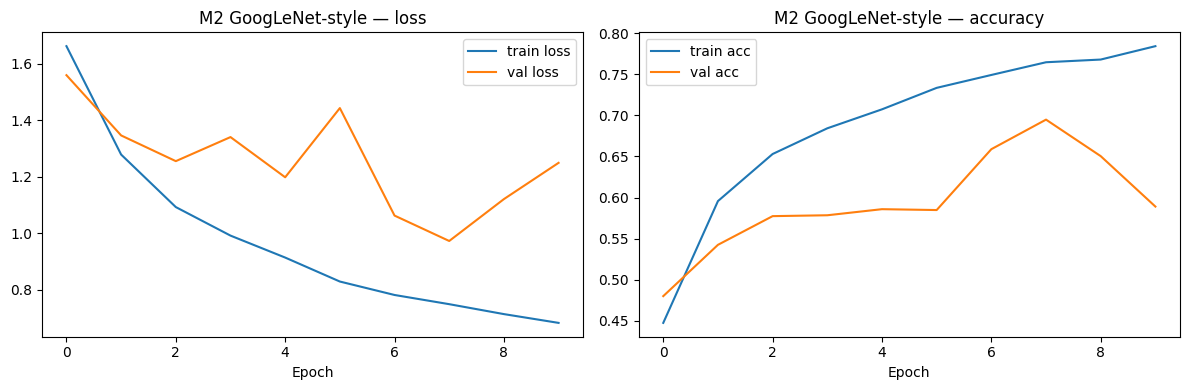

M2 test accuracy: 0.7062


In [23]:
m2 = ModelM2(num_classes=len(class_names)).to(device)
history_m2 = None

if not FORCE_RETRAIN:
    history_m2 = load_checkpoint("M2", m2)
    if history_m2 is not None:
        print("Loaded checkpoint for M2")

if history_m2 is None:
    m2, history_m2 = train_model(m2, train_loader, val_loader)
    save_checkpoint("M2", m2, history_m2)

plot_history(history_m2, "M2 GoogLeNet-style")

y_true_m2, y_pred_m2 = predict_labels(m2, test_loader)
test_metrics_m2 = classification_metrics(y_true_m2, y_pred_m2, class_names)

RESULTS["M2"] = {
    "model": m2,
    "history": history_m2,
    "test_metrics": test_metrics_m2,
    "params": count_parameters(m2),
}
print("M2 test accuracy:", f"{test_metrics_m2['accuracy']:.4f}")

---

# Question 3(d3) — Model $M_3$: ResNet-style variant

### Local change from $M_2$
Keep the Inception-style Stage 2, but replace **only Stage 1** with a residual block:

- conv → BN → ReLU
- conv → BN
- add identity shortcut
- ReLU
- max-pooling

This isolates the effect of a ResNet-style skip connection.

In [24]:
class ResidualStage1(nn.Module):
    def __init__(self, channels=64):
        super().__init__()
        self.conv1 = ConvBNReLU(channels, channels, kernel_size=3, stride=1, padding=1)
        self.conv2 = ConvBN(channels, channels, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.conv2(out)
        out = out + identity
        out = self.relu(out)
        out = self.pool(out)
        return out

class ModelM3(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.stem = CommonStem()
        self.stage1 = ResidualStage1(64)
        self.stage2 = InceptionStage2(64)
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(128, num_classes)

    def forward_features(self, x):
        outputs = {}
        x = self.stem(x)
        outputs["stem"] = x
        x = self.stage1(x)
        outputs["stage1"] = x
        x = self.stage2(x)
        outputs["stage2"] = x
        x = self.gap(x)
        x = torch.flatten(x, 1)
        outputs["gap"] = x
        return outputs

    def forward(self, x):
        feats = self.forward_features(x)
        return self.classifier(feats["gap"])

### Inspect, train, and evaluate $M_3$

In [25]:
m3 = ModelM3(num_classes=len(class_names))
display(inspect_model_shapes(m3))
print("M3 trainable parameters:", f"{count_parameters(m3):,}")

,Location,Shape
0,Input,"(1, 3, 160, 160)"
1,Stem output,"(1, 64, 40, 40)"
2,Stage 1 output,"(1, 64, 20, 20)"
3,Stage 2 output,"(1, 128, 10, 10)"
4,Global average pooling,"(1, 128)"
5,Classifier output,"(1, 10)"


M3 trainable parameters: 122,506


/tmp/ipykernel_16065/4083656842.py:100: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
/tmp/ipykernel_16065/4083656842.py:123: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Epoch 01/10 | train_loss=1.6734 | train_acc=0.4476 | val_loss=1.6538 | val_acc=0.4523
Epoch 02/10 | train_loss=1.2961 | train_acc=0.5897 | val_loss=1.4100 | val_acc=0.5254
Epoch 03/10 | train_loss=1.1275 | train_acc=0.6435 | val_loss=1.1794 | val_acc=0.5964
Epoch 04/10 | train_loss=1.0140 | train_acc=0.6802 | val_loss=1.3543 | val_acc=0.5625
Epoch 05/10 | train_loss=0.9333 | train_acc=0.7083 | val_loss=1.1000 | val_acc=0.6356
Epoch 06/10 | train_loss=0.8750 | train_acc=0.7246 | val_loss=1.4064 | val_acc=0.5424
Epoch 07/10 | train_loss=0.8151 | train_acc=0.7422 | val_loss=1.0504 | val_acc=0.6610
Epoch 08/10 | train_loss=0.7764 | train_acc=0.7540 | val_loss=1.4668 | val_acc=0.5508
Epoch 09/10 | train_loss=0.7295 | train_acc=0.7713 | val_loss=1.1032 | val_acc=0.6621
Epoch 10/10 | train_loss=0.7040 | train_acc=0.7763 | val_loss=1.0073 | val_acc=0.6769
Saved checkpoint to: checkpoints_lab8_q3_reorganized/M3.pt


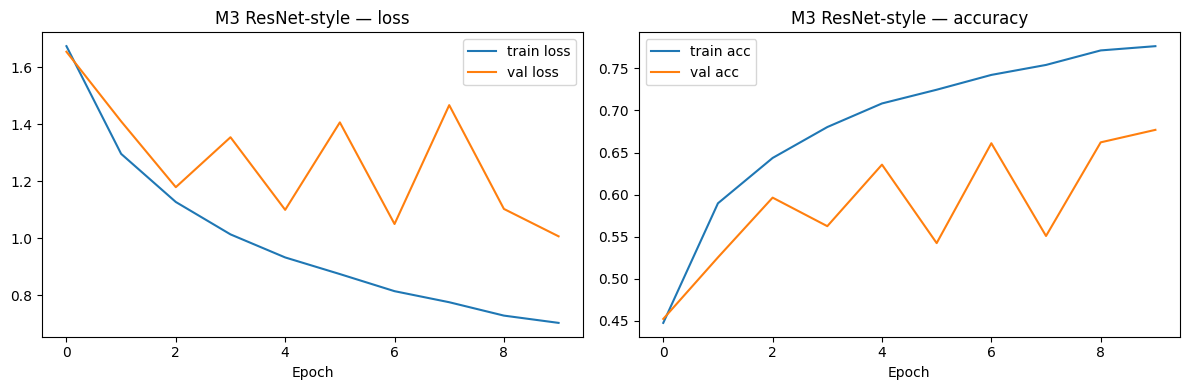

M3 test accuracy: 0.6915


In [26]:
m3 = ModelM3(num_classes=len(class_names)).to(device)
history_m3 = None

if not FORCE_RETRAIN:
    history_m3 = load_checkpoint("M3", m3)
    if history_m3 is not None:
        print("Loaded checkpoint for M3")

if history_m3 is None:
    m3, history_m3 = train_model(m3, train_loader, val_loader)
    save_checkpoint("M3", m3, history_m3)

plot_history(history_m3, "M3 ResNet-style")

y_true_m3, y_pred_m3 = predict_labels(m3, test_loader)
test_metrics_m3 = classification_metrics(y_true_m3, y_pred_m3, class_names)

RESULTS["M3"] = {
    "model": m3,
    "history": history_m3,
    "test_metrics": test_metrics_m3,
    "params": count_parameters(m3),
}
print("M3 test accuracy:", f"{test_metrics_m3['accuracy']:.4f}")

---

# Question 3(d4) — Model $M_4$: MobileNet-style variant

### Local change from $M_3$
Keep the residual structure from $M_3$, but replace the two standard 3×3 convolutions in Stage 1 with **depthwise-separable convolutions**:

1. depthwise 3×3 convolution
2. pointwise 1×1 convolution

This isolates the MobileNet idea of reducing computation and parameters.

In [27]:
class DepthwiseSeparableConvBNReLU(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size,
                      stride=stride, padding=padding,
                      groups=in_channels, bias=False),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class DepthwiseSeparableConvBN(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size,
                      stride=stride, padding=padding,
                      groups=in_channels, bias=False),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
        )

    def forward(self, x):
        return self.block(x)

class ResidualStage1Depthwise(nn.Module):
    def __init__(self, channels=64):
        super().__init__()
        self.conv1 = DepthwiseSeparableConvBNReLU(channels, channels, kernel_size=3, stride=1, padding=1)
        self.conv2 = DepthwiseSeparableConvBN(channels, channels, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.conv2(out)
        out = out + identity
        out = self.relu(out)
        out = self.pool(out)
        return out

class ModelM4(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.stem = CommonStem()
        self.stage1 = ResidualStage1Depthwise(64)
        self.stage2 = InceptionStage2(64)
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(128, num_classes)

    def forward_features(self, x):
        outputs = {}
        x = self.stem(x)
        outputs["stem"] = x
        x = self.stage1(x)
        outputs["stage1"] = x
        x = self.stage2(x)
        outputs["stage2"] = x
        x = self.gap(x)
        x = torch.flatten(x, 1)
        outputs["gap"] = x
        return outputs

    def forward(self, x):
        feats = self.forward_features(x)
        return self.classifier(feats["gap"])

### Inspect, train, and evaluate $M_4$

In [28]:
m4 = ModelM4(num_classes=len(class_names))
display(inspect_model_shapes(m4))
print("M4 trainable parameters:", f"{count_parameters(m4):,}")

,Location,Shape
0,Input,"(1, 3, 160, 160)"
1,Stem output,"(1, 64, 40, 40)"
2,Stage 1 output,"(1, 64, 20, 20)"
3,Stage 2 output,"(1, 128, 10, 10)"
4,Global average pooling,"(1, 128)"
5,Classifier output,"(1, 10)"


M4 trainable parameters: 58,378


/tmp/ipykernel_16065/4083656842.py:100: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
/tmp/ipykernel_16065/4083656842.py:123: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Epoch 01/10 | train_loss=1.6901 | train_acc=0.4393 | val_loss=1.5009 | val_acc=0.4968
Epoch 02/10 | train_loss=1.3005 | train_acc=0.5894 | val_loss=1.3949 | val_acc=0.5265
Epoch 03/10 | train_loss=1.1358 | train_acc=0.6378 | val_loss=1.1216 | val_acc=0.6218
Epoch 04/10 | train_loss=1.0151 | train_acc=0.6740 | val_loss=1.3410 | val_acc=0.5381
Epoch 05/10 | train_loss=0.9258 | train_acc=0.7113 | val_loss=1.0302 | val_acc=0.6706
Epoch 06/10 | train_loss=0.8657 | train_acc=0.7222 | val_loss=1.2306 | val_acc=0.6102
Epoch 07/10 | train_loss=0.8187 | train_acc=0.7381 | val_loss=0.9432 | val_acc=0.6833
Epoch 08/10 | train_loss=0.7851 | train_acc=0.7482 | val_loss=1.0341 | val_acc=0.6769
Epoch 09/10 | train_loss=0.7513 | train_acc=0.7607 | val_loss=1.0466 | val_acc=0.6917
Epoch 10/10 | train_loss=0.7251 | train_acc=0.7707 | val_loss=1.1288 | val_acc=0.6292
Saved checkpoint to: checkpoints_lab8_q3_reorganized/M4.pt


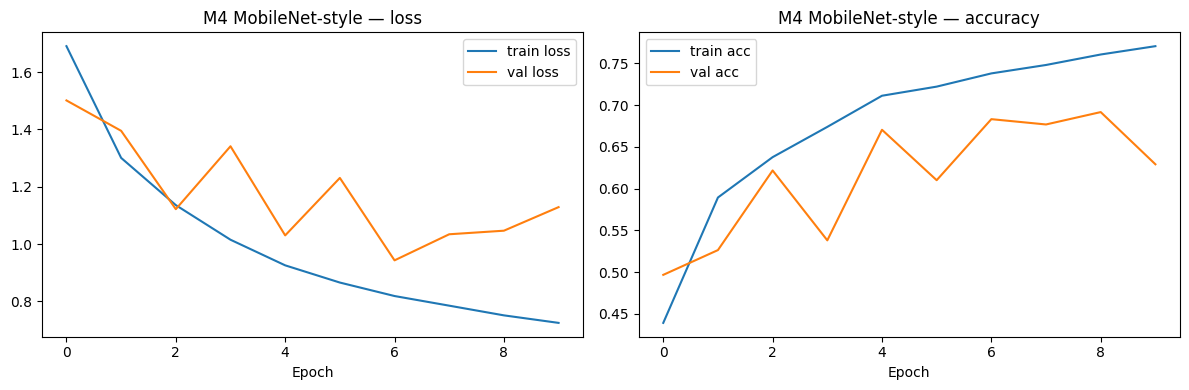

M4 test accuracy: 0.6848


In [29]:
m4 = ModelM4(num_classes=len(class_names)).to(device)
history_m4 = None

if not FORCE_RETRAIN:
    history_m4 = load_checkpoint("M4", m4)
    if history_m4 is not None:
        print("Loaded checkpoint for M4")

if history_m4 is None:
    m4, history_m4 = train_model(m4, train_loader, val_loader)
    save_checkpoint("M4", m4, history_m4)

plot_history(history_m4, "M4 MobileNet-style")

y_true_m4, y_pred_m4 = predict_labels(m4, test_loader)
test_metrics_m4 = classification_metrics(y_true_m4, y_pred_m4, class_names)

RESULTS["M4"] = {
    "model": m4,
    "history": history_m4,
    "test_metrics": test_metrics_m4,
    "params": count_parameters(m4),
}
print("M4 test accuracy:", f"{test_metrics_m4['accuracy']:.4f}")

---

# Question 3(d5) — Model $M_5$: SENet-style variant

### Local change from $M_4$
Keep the MobileNet-style residual stage, but insert an **SE block** after the second depthwise-separable convolution and before shortcut addition.

The SE block performs:
- global average pooling;
- a bottleneck MLP with reduction ratio $r=16$;
- sigmoid gating;
- channel-wise scaling of the feature map.

In [30]:
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(1, channels // reduction)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(channels, hidden)
        self.relu = nn.ReLU(inplace=True)
        self.fc2 = nn.Linear(hidden, channels)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        batch_size, channels, _, _ = x.shape
        s = self.pool(x).view(batch_size, channels)
        s = self.fc1(s)
        s = self.relu(s)
        s = self.fc2(s)
        s = self.sigmoid(s).view(batch_size, channels, 1, 1)
        return x * s

class ResidualStage1DepthwiseSE(nn.Module):
    def __init__(self, channels=64, reduction=16):
        super().__init__()
        self.conv1 = DepthwiseSeparableConvBNReLU(channels, channels, kernel_size=3, stride=1, padding=1)
        self.conv2 = DepthwiseSeparableConvBN(channels, channels, kernel_size=3, stride=1, padding=1)
        self.se = SEBlock(channels, reduction=reduction)
        self.relu = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.conv2(out)
        out = self.se(out)
        out = out + identity
        out = self.relu(out)
        out = self.pool(out)
        return out

class ModelM5(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.stem = CommonStem()
        self.stage1 = ResidualStage1DepthwiseSE(64, reduction=16)
        self.stage2 = InceptionStage2(64)
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(128, num_classes)

    def forward_features(self, x):
        outputs = {}
        x = self.stem(x)
        outputs["stem"] = x
        x = self.stage1(x)
        outputs["stage1"] = x
        x = self.stage2(x)
        outputs["stage2"] = x
        x = self.gap(x)
        x = torch.flatten(x, 1)
        outputs["gap"] = x
        return outputs

    def forward(self, x):
        feats = self.forward_features(x)
        return self.classifier(feats["gap"])

### Inspect, train, and evaluate $M_5$

In [31]:
m5 = ModelM5(num_classes=len(class_names))
display(inspect_model_shapes(m5))
print("M5 trainable parameters:", f"{count_parameters(m5):,}")

,Location,Shape
0,Input,"(1, 3, 160, 160)"
1,Stem output,"(1, 64, 40, 40)"
2,Stage 1 output,"(1, 64, 20, 20)"
3,Stage 2 output,"(1, 128, 10, 10)"
4,Global average pooling,"(1, 128)"
5,Classifier output,"(1, 10)"


M5 trainable parameters: 58,958


/tmp/ipykernel_16065/4083656842.py:100: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
/tmp/ipykernel_16065/4083656842.py:123: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Epoch 01/10 | train_loss=1.6878 | train_acc=0.4526 | val_loss=1.4535 | val_acc=0.5191
Epoch 02/10 | train_loss=1.2952 | train_acc=0.5932 | val_loss=1.3164 | val_acc=0.5614
Epoch 03/10 | train_loss=1.1027 | train_acc=0.6523 | val_loss=1.1235 | val_acc=0.6356
Epoch 04/10 | train_loss=0.9810 | train_acc=0.6862 | val_loss=1.2768 | val_acc=0.5742
Epoch 05/10 | train_loss=0.9006 | train_acc=0.7141 | val_loss=0.9900 | val_acc=0.6758
Epoch 06/10 | train_loss=0.8381 | train_acc=0.7347 | val_loss=0.8945 | val_acc=0.7055
Epoch 07/10 | train_loss=0.7872 | train_acc=0.7448 | val_loss=1.1232 | val_acc=0.6388
Epoch 08/10 | train_loss=0.7462 | train_acc=0.7601 | val_loss=0.9148 | val_acc=0.6949
Epoch 09/10 | train_loss=0.7039 | train_acc=0.7769 | val_loss=1.0699 | val_acc=0.6504
Epoch 10/10 | train_loss=0.6911 | train_acc=0.7752 | val_loss=0.9586 | val_acc=0.6854
Saved checkpoint to: checkpoints_lab8_q3_reorganized/M5.pt


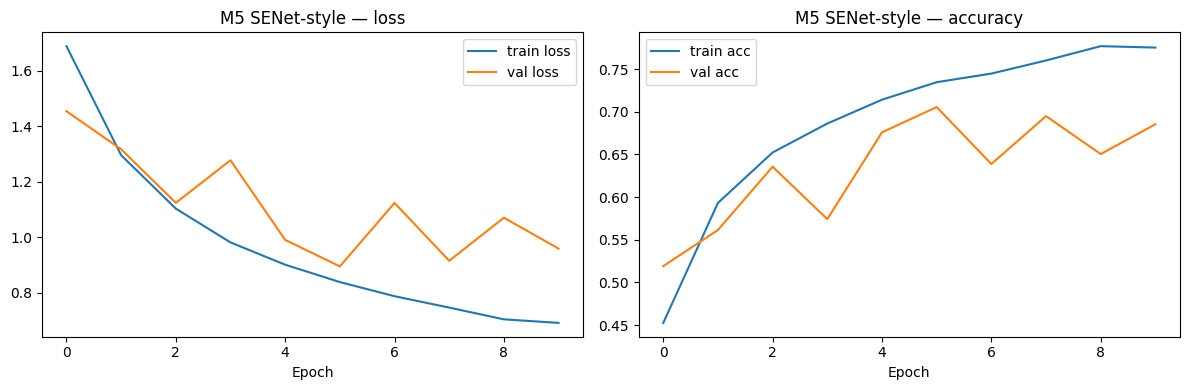

M5 test accuracy: 0.7279


In [32]:
m5 = ModelM5(num_classes=len(class_names)).to(device)
history_m5 = None

if not FORCE_RETRAIN:
    history_m5 = load_checkpoint("M5", m5)
    if history_m5 is not None:
        print("Loaded checkpoint for M5")

if history_m5 is None:
    m5, history_m5 = train_model(m5, train_loader, val_loader)
    save_checkpoint("M5", m5, history_m5)

plot_history(history_m5, "M5 SENet-style")

y_true_m5, y_pred_m5 = predict_labels(m5, test_loader)
test_metrics_m5 = classification_metrics(y_true_m5, y_pred_m5, class_names)

RESULTS["M5"] = {
    "model": m5,
    "history": history_m5,
    "test_metrics": test_metrics_m5,
    "params": count_parameters(m5),
}
print("M5 test accuracy:", f"{test_metrics_m5['accuracy']:.4f}")

## 8. Comparison table for all models

Now that each model was implemented in its own subsection, we can compare them fairly under the same training setup.

In [33]:
comparison_rows = []
for model_name in ["M0", "M1", "M2", "M3", "M4", "M5"]:
    result = RESULTS[model_name]
    metrics = result["test_metrics"]
    comparison_rows.append({
        "Model": model_name,
        "Trainable Parameters": result["params"],
        "Test Accuracy": metrics["accuracy"],
        "Macro Precision": metrics["macro_precision"],
        "Macro Recall": metrics["macro_recall"],
        "Macro F1": metrics["macro_f1"],
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
display(comparison_df)

,Model,Trainable Parameters,Test Accuracy,Macro Precision,Macro Recall,Macro F1
0,M5,58958,0.727898,0.732871,0.728225,0.724009
1,M1,316458,0.717707,0.738894,0.716153,0.711982
2,M2,122506,0.706242,0.732298,0.707520,0.698261
3,M0,131754,0.699618,0.720582,0.699596,0.698800
4,M3,122506,0.691465,0.733842,0.694088,0.685078
5,M4,58378,0.684841,0.727876,0.686944,0.679348


## 9. Required detailed reports for $M_0$, $M_2$, and $M_5$

The assignment only asks for full confusion-matrix and per-class reports for:
- the baseline model $M_0$;
- the GoogLeNet-style model $M_2$;
- the final SENet-style model $M_5$.

Detailed report for M0
Accuracy: 0.6996
Macro Precision: 0.7206
Macro Recall: 0.6996
Macro F1: 0.6988


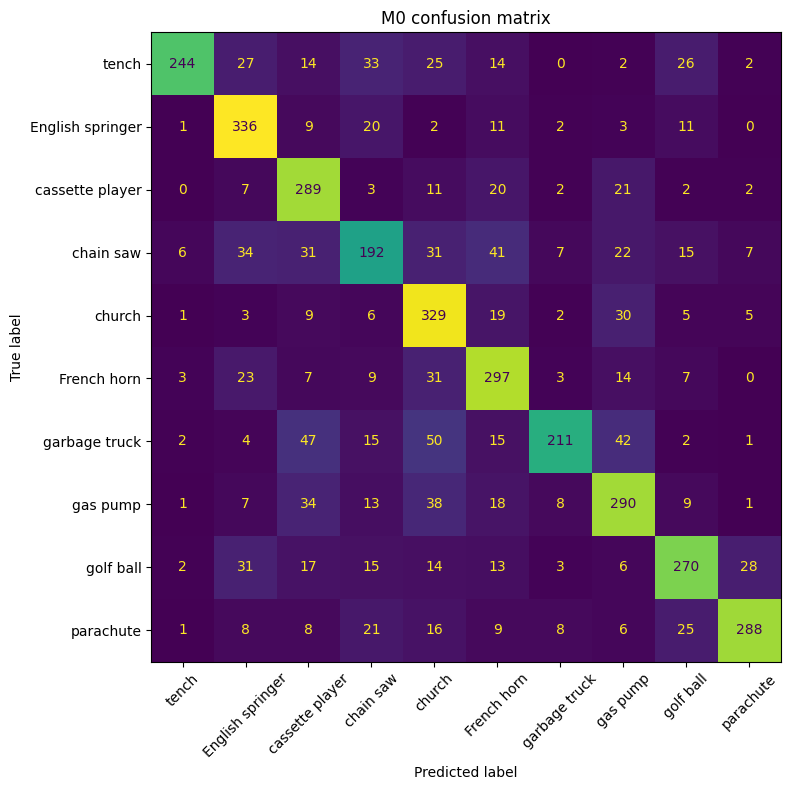

,precision,recall,f1-score,support
tench,0.934866,0.630491,0.753086,387.0
English springer,0.700000,0.850633,0.768000,395.0
cassette player,0.621505,0.809524,0.703163,357.0
chain saw,0.587156,0.497409,0.538569,386.0
church,0.601463,0.804401,0.688285,409.0
French horn,0.649891,0.753807,0.698002,394.0
garbage truck,0.857724,0.542416,0.664567,389.0
gas pump,0.665138,0.692124,0.678363,419.0
golf ball,0.725806,0.676692,0.700389,399.0
parachute,0.862275,0.738462,0.795580,390.0


Detailed report for M2
Accuracy: 0.7062
Macro Precision: 0.7323
Macro Recall: 0.7075
Macro F1: 0.6983


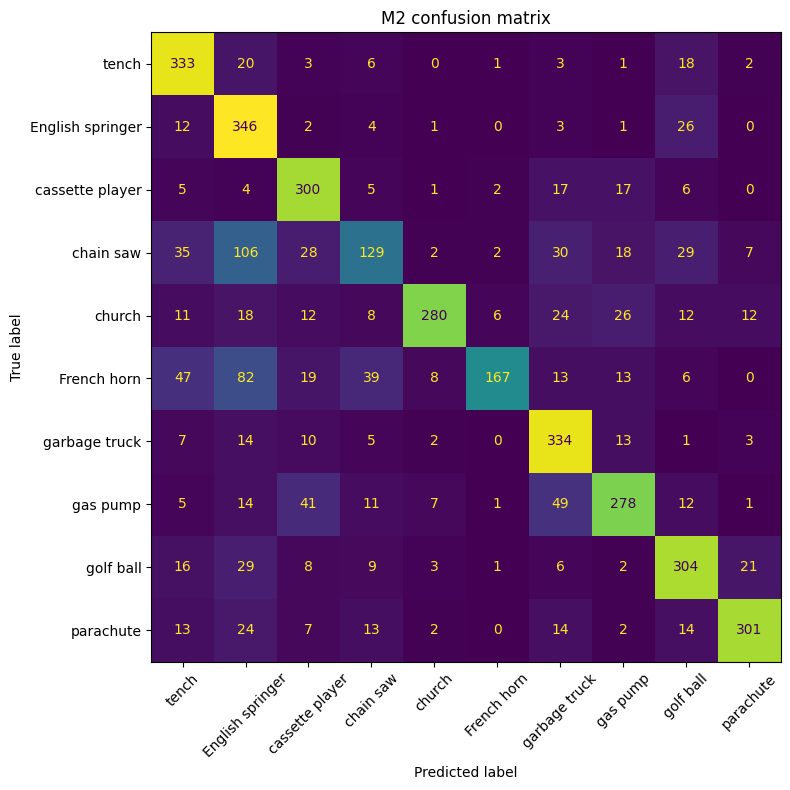

,precision,recall,f1-score,support
tench,0.688017,0.860465,0.764638,387.0
English springer,0.526636,0.875949,0.657795,395.0
cassette player,0.697674,0.840336,0.762389,357.0
chain saw,0.563319,0.334197,0.419512,386.0
church,0.915033,0.684597,0.783217,409.0
French horn,0.927778,0.423858,0.581882,394.0
garbage truck,0.677485,0.858612,0.757370,389.0
gas pump,0.749326,0.663484,0.703797,419.0
golf ball,0.710280,0.761905,0.735187,399.0
parachute,0.867435,0.771795,0.816825,390.0


Detailed report for M5
Accuracy: 0.7279
Macro Precision: 0.7329
Macro Recall: 0.7282
Macro F1: 0.7240


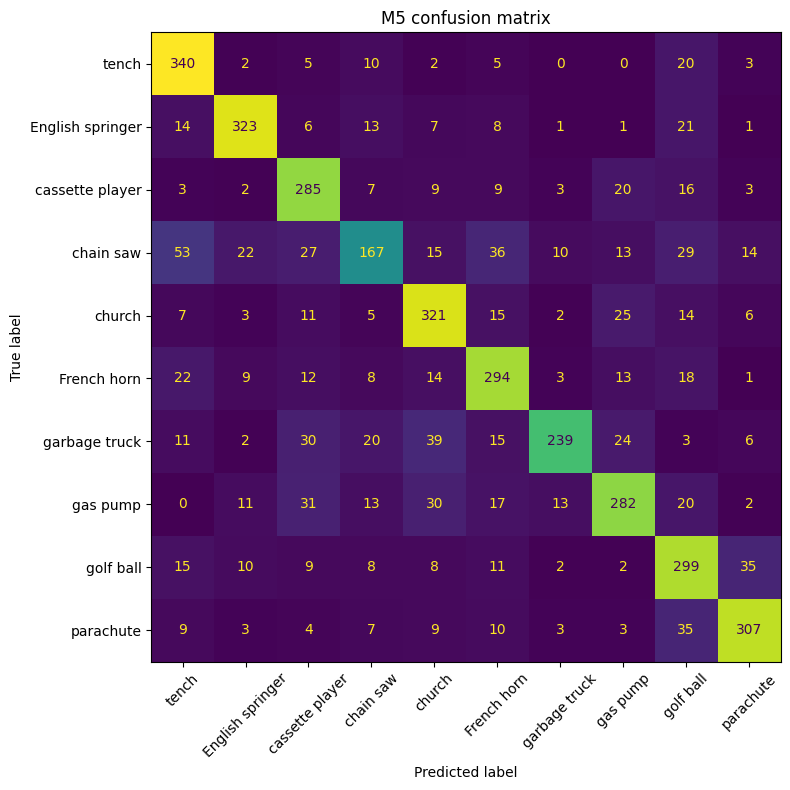

,precision,recall,f1-score,support
tench,0.717300,0.878553,0.789779,387.0
English springer,0.834625,0.817722,0.826087,395.0
cassette player,0.678571,0.798319,0.733591,357.0
chain saw,0.647287,0.432642,0.518634,386.0
church,0.707048,0.784841,0.743917,409.0
French horn,0.700000,0.746193,0.722359,394.0
garbage truck,0.865942,0.614396,0.718797,389.0
gas pump,0.736292,0.673031,0.703242,419.0
golf ball,0.629474,0.749373,0.684211,399.0
parachute,0.812169,0.787179,0.799479,390.0


In [34]:
for model_name in ["M0", "M2", "M5"]:
    print("=" * 80)
    print(f"Detailed report for {model_name}")
    metrics = RESULTS[model_name]["test_metrics"]
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Macro Precision: {metrics['macro_precision']:.4f}")
    print(f"Macro Recall: {metrics['macro_recall']:.4f}")
    print(f"Macro F1: {metrics['macro_f1']:.4f}")
    plot_confusion(metrics["confusion_matrix"], class_names, f"{model_name} confusion matrix")
    display(metrics["report_df"])

## 10. Question 3(e) — Discussion prompts

Use your own experimental results to write discussion.

Your discussion should comment on both:
- **predictive performance**
- **model efficiency** (parameter count and/or computational cost)

A strong discussion addresses:
1. baseline serial CNN → VGG-style deepening
2. VGG-style → GoogLeNet-style branching
3. GoogLeNet-style → ResNet-style shortcut
4. ResNet-style → MobileNet-style depthwise separable convolution
5. MobileNet-style → SENet-style channel attention

### Reference interpretation

A strong answer should explain the role of each architectural change rather than only saying whether accuracy increased.

- **M0 → M1:** deeper serial 3×3 blocks usually improve feature extraction, but increase parameter count.
- **M1 → M2:** multi-branch processing captures multiple receptive-field sizes in parallel.
- **M2 → M3:** residual shortcuts usually improve information flow and make optimization easier.
- **M3 → M4:** depthwise-separable convolutions reduce parameter count and computation substantially, often with only a modest performance drop.
- **M4 → M5:** channel attention reweights feature channels and may improve performance with relatively small overhead.

## 11. Optional: save the comparison table


In [35]:
OUTPUT_DIR = Path("./outputs_lab8_q3_reorganized")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

comparison_path = OUTPUT_DIR / "q3_model_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)
print(f"Saved comparison table to: {comparison_path}")

Saved comparison table to: outputs_lab8_q3_reorganized/q3_model_comparison.csv
